# Gradient Boosting Regressor (GBR)

**Full feature set (no PCA)**

Author: Pete King

This notebook simply recreates the analysis from our grid search notebook using the optimized hyperparameters we found there.  It runs much faster without the grid search and we simply use it for convenience to reproduce results.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'

## I. Import data


In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels
# Include all input features, including return data
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

Here we select several hyperparameters that we chose using a grid search method.  The lower learning rate balances a larger number of estimators: the combined effect is similar taking a larger sample of weak learners and taking their average, introducing a greater degree of regularization.  The reduced number of features for each stage and reduced maximum tree depth both serve to reduce the model's tendency to overfit to training data and should improve generalization.

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.05,
    max_features='sqrt',
    max_depth=2,
    n_estimators= 150
)

In [5]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'absolute_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

### Visualize performance; Check evaluation metrics

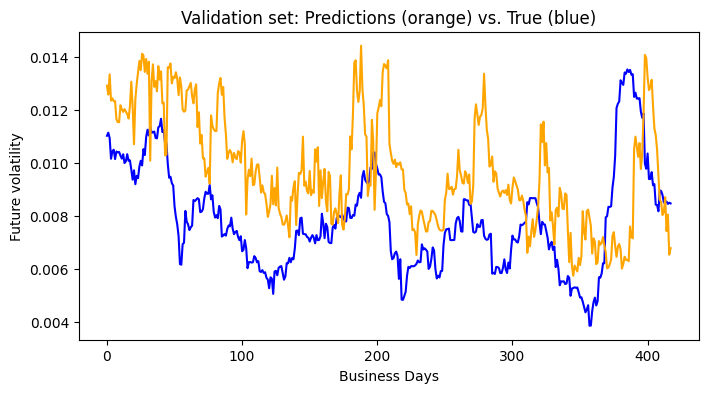

In [6]:
# Use the best estimator to make predictions on the validation set
# best = reg.best_estimator_
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [7]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.00254992811935321
R2: -1.315259217367629


Results for this run may not match exactly to the results from our grid search due to the stochastic nature of the mode, but they do appear to be very close.  Visually though, the predictions from this model look markedly different from the predictions we got from our grid search model, even if both models tend to show the same general ability to predict trends in future volatility while suffering from pronounced lag.

## III. Inspect model


In [8]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

XLY_vol-h: 0.107
^VIX: 0.092
real_GDP_chg: 0.085
^VXN: 0.056
XLRE_vol-h: 0.047
debt_to_GDP_chg: 0.043
^GSPC_vol-h: 0.041
XLV_vol-h: 0.029
IEF_vol-h: 0.029
LQD_vol-h: 0.027
XLI_ret-h: 0.021
core_PCE_chg: 0.021
unemployment_rate_chg: 0.019
nominal_GDP_chg: 0.019
average_duration_of_unemployment_chg: 0.019
core_PCI_chg: 0.018
NG=F_vol-h: 0.017
^MOVE: 0.016
debt_interest_chg: 0.016
SPY_ret-h: 0.015
female_unemployment_rate_chg: 0.015
^HSI_vol-h: 0.013
SPY_vol-h: 0.013
XLK_vol-h: 0.012
TIP_vol-h: 0.012
XLP_vol-h: 0.012
BIL_vol-h: 0.012
producer_price_index_chg: 0.011
XLF_vol-h: 0.011
XLE_vol-h: 0.010
teenager_unemployment_rate_chg: 0.009
XLV_ret-h: 0.009
BIL_ret-h: 0.008
BND_vol-h: 0.008
HYG_vol-h: 0.008
XLI_vol-h: 0.007
QQQ_ret-h: 0.007
personal_consumption_expenditure_chg: 0.006
GLD_vol-h: 0.006
TLT_vol-h: 0.006
LQD_ret-h: 0.005
SHY_vol-h: 0.005
GLD_ret-h: 0.005
GC=F_vol-h: 0.004
BND_ret-h: 0.004
HYG_ret-h: 0.004
QQQ_vol-h: 0.004
adult_unemployment_rate_chg: 0.004
male_unemployment_rate_c

Interestingly, we see a different ranking of feature importances on this run of the model, even though in theory it should be identical to our grid search.  Feature importances are very similar, with the same set of features still high on the list (e.g., ^VIX, real_GDP_chg, and XLY_vol-h), but in a different order.  Again we expect this is due to the stochastic nature of the model.